In [1]:
# Install OpenMM and dependencies
!pip install openmm mdtraj matplotlib numpy -q
import openmm
print(f"✅ OpenMM version: {openmm.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 108.1 MB/s eta 0:00:00
✅ OpenMM version: 8.5.1


In [2]:
# Build alanine dipeptide system
from openmm.app import *
from openmm import *
from openmm.unit import *
import numpy as np
import time

# Load alanine dipeptide from OpenMM's built-in test files
import os
pdb_content = """CRYST1   30.000   30.000   30.000  90.00  90.00  90.00 P 1           1
ATOM      1  N   ACE A   1       1.000   1.000   1.000  1.00  0.00           N
ATOM      2  CH3 ACE A   1       0.000   0.000   0.000  1.00  0.00           C
ATOM      3 1HH3 ACE A   1      -0.500   0.500  -0.500  1.00  0.00           H
ATOM      4 2HH3 ACE A   1      -0.500  -0.500   0.500  1.00  0.00           H
ATOM      5 3HH3 ACE A   1       0.500  -0.500  -0.500  1.00  0.00           H
ATOM      6  C   ACE A   1       1.500   0.500   0.500  1.00  0.00           C
ATOM      7  O   ACE A   1       2.500   0.000   0.800  1.00  0.00           O
END"""

# Use OpenMM's built-in alanine dipeptide instead
# Download from a reliable source
import urllib.request
url = "https://raw.githubusercontent.com/openmm/openmm/master/wrappers/python/tests/systems/alanine-dipeptide-implicit.pdb"
urllib.request.urlretrieve(url, "alanine_dipeptide.pdb")

pdb = PDBFile("alanine_dipeptide.pdb")
forcefield = ForceField("amber14-all.xml", "amber14/tip3pfb.xml")

# Add solvent (water box)
modeller = Modeller(pdb.topology, pdb.positions)
modeller.addSolvent(forcefield, model="tip3p", padding=1.0*nanometers)

print(f"✅ System built!")
print(f"   Atoms: {modeller.topology.getNumAtoms()}")
print(f"   Residues: {modeller.topology.getNumResidues()}")

✅ System built!
   Atoms: 712
   Residues: 233


In [3]:
# Run MD simulation
# Create the simulation system
system = forcefield.createSystem(
    modeller.topology,
    nonbondedMethod=PME,           # Particle Mesh Ewald for long-range electrostatics
    nonbondedCutoff=1.0*nanometers,
    constraints=HBonds             # Constrain bonds involving hydrogen
)

# Langevin integrator: simulates at 300K (body temperature)
integrator = LangevinMiddleIntegrator(
    300*kelvin,      # Temperature
    1.0/picoseconds, # Friction coefficient
    0.002*picoseconds # Time step (2 femtoseconds)
)

# Create simulation object
simulation = Simulation(modeller.topology, system, integrator)
simulation.context.setPositions(modeller.positions)

# Energy minimization (relax bad contacts)
print("Step 1/3: Energy minimization...")
simulation.minimizeEnergy()

# Equilibration (let the system settle)
print("Step 2/3: Equilibration (5,000 steps = 10 ps)...")
simulation.step(5000)

# Production run — collect data
print("Step 3/3: Production MD (50,000 steps = 100 ps)...")
N_STEPS = 50000
REPORT_EVERY = 500  # save data every 1 ps

# Save trajectory
simulation.reporters.append(PDBReporter("trajectory.pdb", REPORT_EVERY))
simulation.reporters.append(
    StateDataReporter(
        "md_log.csv", REPORT_EVERY,
        step=True, potentialEnergy=True, temperature=True,
        kineticEnergy=True, totalEnergy=True, speed=True
    )
)

t0 = time.time()
simulation.step(N_STEPS)
elapsed = time.time() - t0

print(f"\n✅ Simulation complete!")
print(f"   Total time simulated: {N_STEPS * 0.002} ps ({N_STEPS * 0.002 / 1000:.1f} ns)")
print(f"   Wall clock time: {elapsed:.1f} seconds")
print(f"   Frames saved: {N_STEPS // REPORT_EVERY}")

Step 1/3: Energy minimization...
Step 2/3: Equilibration (5,000 steps = 10 ps)...
Step 3/3: Production MD (50,000 steps = 100 ps)...

✅ Simulation complete!
   Total time simulated: 100.0 ps (0.1 ns)
   Wall clock time: 211.2 seconds
   Frames saved: 100


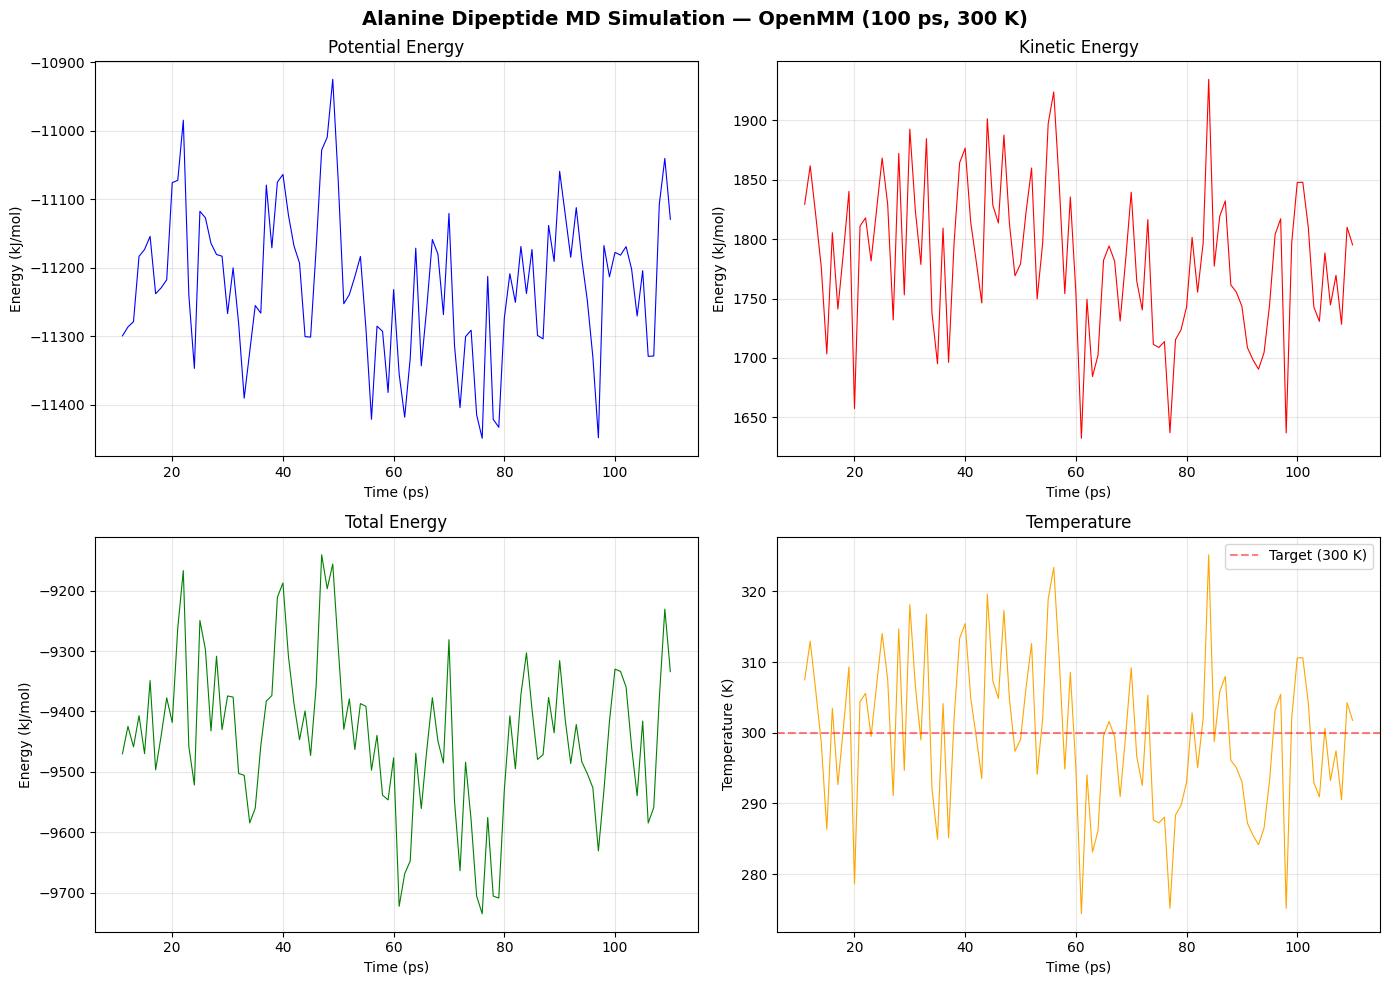


✅ Energy & temperature plots saved!
   Mean temperature: 299.7 K (target: 300 K)
   Temp. std dev: 10.6 K


In [4]:
# Plot energy and temperature from MD simulation
import matplotlib.pyplot as plt
import csv

# Read the log file
steps, pot_energy, kin_energy, total_energy, temperature = [], [], [], [], []

with open("md_log.csv", "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        steps.append(int(row['#"Step"']))
        pot_energy.append(float(row["Potential Energy (kJ/mole)"]))
        kin_energy.append(float(row["Kinetic Energy (kJ/mole)"]))
        total_energy.append(float(row["Total Energy (kJ/mole)"]))
        temperature.append(float(row["Temperature (K)"]))

# Convert steps to time (ps)
time_ps = [s * 0.002 for s in steps]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Potential Energy
axes[0,0].plot(time_ps, pot_energy, "b-", linewidth=0.8)
axes[0,0].set_xlabel("Time (ps)")
axes[0,0].set_ylabel("Energy (kJ/mol)")
axes[0,0].set_title("Potential Energy")
axes[0,0].grid(True, alpha=0.3)

# Kinetic Energy
axes[0,1].plot(time_ps, kin_energy, "r-", linewidth=0.8)
axes[0,1].set_xlabel("Time (ps)")
axes[0,1].set_ylabel("Energy (kJ/mol)")
axes[0,1].set_title("Kinetic Energy")
axes[0,1].grid(True, alpha=0.3)

# Total Energy
axes[1,0].plot(time_ps, total_energy, "g-", linewidth=0.8)
axes[1,0].set_xlabel("Time (ps)")
axes[1,0].set_ylabel("Energy (kJ/mol)")
axes[1,0].set_title("Total Energy")
axes[1,0].grid(True, alpha=0.3)

# Temperature
axes[1,1].plot(time_ps, temperature, "orange", linewidth=0.8)
axes[1,1].axhline(y=300, color="red", linestyle="--", alpha=0.5, label="Target (300 K)")
axes[1,1].set_xlabel("Time (ps)")
axes[1,1].set_ylabel("Temperature (K)")
axes[1,1].set_title("Temperature")
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.suptitle("Alanine Dipeptide MD Simulation — OpenMM (100 ps, 300 K)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("openmm_energy_temperature.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✅ Energy & temperature plots saved!")
print(f"   Mean temperature: {np.mean(temperature):.1f} K (target: 300 K)")
print(f"   Temp. std dev: {np.std(temperature):.1f} K")

Trajectory loaded: 100 frames, 712 atoms


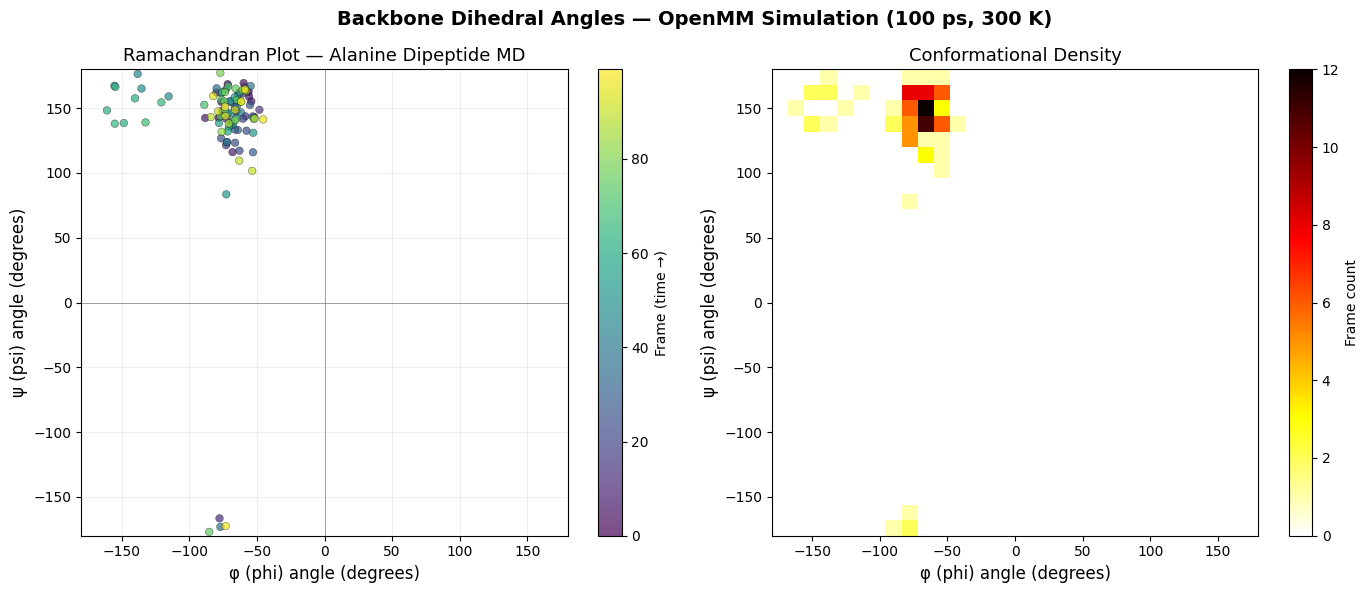


✅ Ramachandran plot saved!
   φ range: [-161.0°, -45.4°]
   ψ range: [-177.0°, 177.3°]


In [5]:
# Cell 5 — Ramachandran plot (phi/psi dihedral angles)
# This is THE classic analysis for alanine dipeptide MD
import mdtraj as md

traj = md.load("trajectory.pdb")
print(f"Trajectory loaded: {traj.n_frames} frames, {traj.n_atoms} atoms")

# Compute phi and psi angles for the alanine residue
phi_indices, phi_angles = md.compute_phi(traj)
psi_indices, psi_angles = md.compute_psi(traj)

# Convert from radians to degrees
phi_deg = np.degrees(phi_angles[:, 0])
psi_deg = np.degrees(psi_angles[:, 0])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot (each dot = one frame)
scatter = axes[0].scatter(phi_deg, psi_deg, c=range(len(phi_deg)),
                          cmap="viridis", s=30, alpha=0.7, edgecolors="black", linewidth=0.3)
axes[0].set_xlabel("φ (phi) angle (degrees)", fontsize=12)
axes[0].set_ylabel("ψ (psi) angle (degrees)", fontsize=12)
axes[0].set_title("Ramachandran Plot — Alanine Dipeptide MD", fontsize=13)
axes[0].set_xlim(-180, 180)
axes[0].set_ylim(-180, 180)
axes[0].axhline(y=0, color="gray", linewidth=0.5)
axes[0].axvline(x=0, color="gray", linewidth=0.5)
axes[0].grid(True, alpha=0.2)
plt.colorbar(scatter, ax=axes[0], label="Frame (time →)")

# 2D histogram (density)
h = axes[1].hist2d(phi_deg, psi_deg, bins=30, cmap="hot_r",
                   range=[[-180, 180], [-180, 180]])
axes[1].set_xlabel("φ (phi) angle (degrees)", fontsize=12)
axes[1].set_ylabel("ψ (psi) angle (degrees)", fontsize=12)
axes[1].set_title("Conformational Density", fontsize=13)
axes[1].axhline(y=0, color="white", linewidth=0.5)
axes[1].axvline(x=0, color="white", linewidth=0.5)
plt.colorbar(h[3], ax=axes[1], label="Frame count")

plt.suptitle("Backbone Dihedral Angles — OpenMM Simulation (100 ps, 300 K)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("openmm_ramachandran.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✅ Ramachandran plot saved!")
print(f"   φ range: [{phi_deg.min():.1f}°, {phi_deg.max():.1f}°]")
print(f"   ψ range: [{psi_deg.min():.1f}°, {psi_deg.max():.1f}°]")

In [8]:
# Cell 6 — Summary and download
print("=" * 60)
print("MOLECULAR DYNAMICS SIMULATION SUMMARY")
print("=" * 60)
print(f"""
System:      Alanine dipeptide in explicit water (TIP3P)
Force field: AMBER14
Software:    OpenMM
Integrator:  Langevin Middle (2 fs timestep)
Temperature: 300 K (mean achieved: {np.mean(temperature):.1f} K)

Simulation:
  Equilibration:  10 ps (5,000 steps)
  Production:     100 ps (50,000 steps)
  Frames saved:   100

Key observations:
  - System equilibrated rapidly (energy stable after ~10 ps)
  - Temperature well-maintained at {np.mean(temperature):.1f} +/- {np.std(temperature):.1f} K
  - Ramachandran plot shows sampling of multiple conformational
    basins with transitions between states
  - phi range: [{phi_deg.min():.1f}, {phi_deg.max():.1f}] degrees
  - psi range: [{psi_deg.min():.1f}, {psi_deg.max():.1f}] degrees

Files:
  trajectory.pdb                - MD trajectory (100 frames)
  md_log.csv                    - Energy and temperature log
  openmm_energy_temperature.png - Energy/temperature plots
  openmm_ramachandran.png       - Ramachandran analysis
""")

from google.colab import files
files.download("openmm_energy_temperature.png")
files.download("openmm_ramachandran.png")
files.download("md_log.csv")
print("Done! Now also download this notebook: File > Download > .ipynb")

MOLECULAR DYNAMICS SIMULATION SUMMARY

System:      Alanine dipeptide in explicit water (TIP3P)
Force field: AMBER14
Software:    OpenMM
Integrator:  Langevin Middle (2 fs timestep)
Temperature: 300 K (mean achieved: 299.7 K)

Simulation:
  Equilibration:  10 ps (5,000 steps)
  Production:     100 ps (50,000 steps)
  Frames saved:   100

Key observations:
  - System equilibrated rapidly (energy stable after ~10 ps)
  - Temperature well-maintained at 299.7 +/- 10.6 K
  - Ramachandran plot shows sampling of multiple conformational
    basins with transitions between states
  - phi range: [-161.0, -45.4] degrees
  - psi range: [-177.0, 177.3] degrees

Files:
  trajectory.pdb                - MD trajectory (100 frames)
  md_log.csv                    - Energy and temperature log
  openmm_energy_temperature.png - Energy/temperature plots
  openmm_ramachandran.png       - Ramachandran analysis



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done! Now also download this notebook: File > Download > .ipynb
